In [1]:
import argparse
import json
import os
import tempfile
import numpy as np
import subprocess
from tqdm import tqdm
import pandas as pd
import datetime
import time
import gc
import random
import sys
import shutil
import glob

sys.path.append("/home/agustin/phd/synthesis")
sys.path.append(
    "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/test4_finetune_brainst_diffusion_model/training/networks_declaration"
)


# pytorch
import torch
from torch.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from torch.utils.checkpoint import checkpoint
from torch.utils.data import Dataset, Sampler
import torch.distributed as dist

# data loader
from sklearn.preprocessing import MinMaxScaler

# mine
import utils.nifti_functions as nfc
import utils.util as util
import utils.functions as fc
import utils.util_freesurfer_segmentation as ufs
import utils.gpu_selector as gpu_selector
import data_loaders.load_dataset as load_dataset
import utils.data_normalization as data_normalization

# monai
from monai.bundle import ConfigParser

import networks_declaration.diffusion_model_unet_maisi_mask_seg as diffusion_model_unet_maisi
import networks_declaration.segmentation_encoder as segmentation_encoder
import networks_declaration.conditions_model as conditions_model

# import attention_controller as attention_controller
from networks_declaration.rectified_flow import RFlowScheduler

# from monai.networks.schedulers.rectified_flow import RFlowScheduler
from monai.networks.schedulers.ddpm import DDPMPredictionType

# images
from PIL import Image

sys.path.append("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils")
from autoencoder_declaration import AutoencoderPrediction
import prep_image as prep_image

# device_name = f"cuda:{gpu_selector.get_least_used_gpu()}"
device_name = f"cuda:1"
device = torch.device(device_name)


def set_seed(seed: int):
    # random.seed(seed)  # Semilla para Python
    np.random.seed(seed)  # Semilla para NumPy
    torch.manual_seed(seed)  # Semilla para PyTorch en CPU
    torch.cuda.manual_seed(seed)  # Semilla para PyTorch en GPU
    torch.cuda.manual_seed_all(seed)  # Semilla para todas las GPUs
    torch.backends.cudnn.deterministic = True  # Garantizar reproducibilidad en CNNs
    torch.backends.cudnn.benchmark = False  # Desactivar optimización no determinista


In [2]:
import prep_histogram as prep_histogram
from scipy.ndimage import gaussian_filter

def add_gaussian_noise(image, mask, sigma=0.05):
    noise = np.random.normal(0, sigma, image.shape)
    noisy_image = image + noise
    # clip to 0-1 range
    noisy_image = np.clip(noisy_image, 0, 1)
    noisy_image[mask == 0] = 0
    return noisy_image


def transform_image(
    src_img,
    src_seg,
    x_noise,
    x_sigma,
    x_power,
    histogram_reference,
    tissues_idx=[1, 2, 3],
    tissuewise_histogram_matching=False
):
    """
    Apply the complete transformation pipeline.
    """

    # # Histogram matching
    if tissuewise_histogram_matching:
        c_img_histmatched = prep_histogram.match_histogram_quantiles_tissuewise(
            src_img, 
            src_seg, 
            histogram_reference, 
            brain_mask=src_seg>0, 
            tissues_idx=tissues_idx)
    else:
        c_img_histmatched = prep_histogram.match_hist_with_reference(
            src_img,
            histogram_reference,
            mask=src_seg
        )


    # Noise
    c_img_noisy = add_gaussian_noise(
        c_img_histmatched,
        src_seg,
        x_noise
    )


    # Gaussian smoothing
    c_img_gaussian = gaussian_filter(
        c_img_noisy,
        sigma=x_sigma
    )

    # Power transform
    c_img_final = np.power(
        c_img_gaussian,
        x_power
    )

    return c_img_final

In [3]:
# BLURRING_INTERVALS = {
#     "T1W": {
#             0.1: (2.0, 2.5),
#             1.5: (1.0, 1.5),
#             3: (0.5, 1.0),
#             5: (0.25, 0.5),
#     },
#     "T2W": {
#         0.1: (2.2, 3.0),
#         1.5: (1.0, 1.5),
#         3: (0.5, 1.0),
#         5: (0.25, 0.5),
#     },
#     "T2FLAIR": {
#         0.1: (2.2, 3.0),
#         1.5: (1.0, 1.5),
#         3: (0.5, 1.0),
#         5: (0.25, 0.5),
#     }
# }

# GAMMA_INTERVALS = {
#     "T1W": {
#             0.1: (0.9, 1.1),
#             1.5: (0.7, 1.0),
#             3: (0.4, 0.7),
#             5: (1.0, 1.3),
#     },
#     "T2W": {
#         0.1: (1.0, 1.4),
#         1.5: (1.0, 1.1),
#         3: (0.9, 1.1),
#         5: (0.9, 1.0),
#     },
#     "T2FLAIR": {
#         0.1: (1.0, 1.4),
#         1.5: (1.0, 1.1),
#         3: (0.9, 1.1),
#         5: (0.9, 1.0),
#     }
# }

# NOISE_INTERVALS = {
#     "T1W": {
#             0.1: (0.001, 0.02),
#             1.5: (0.001, 0.01),
#             3: (0.001, 0.005),
#             5: (0.001, 0.005),
#     },
#     "T2W": {
#         0.1: (0.001, 0.02),
#         1.5: (0.001, 0.01),
#         3: (0.001, 0.005),
#         5: (0.001, 0.005),
#     },
#     "T2FLAIR": {
#         0.1: (0.001, 0.02),
#         1.5: (0.001, 0.01),
#         3: (0.001, 0.005),
#         5: (0.001, 0.005),
#     }
# }





BLURRING_INTERVALS = {
    "T1W": {
        0.1: (2.0, 6.0),
        1.5: (1.0, 2.0),
        3: (0.5, 1.5),
        5: (0.25, 0.5),
    },
    "T2W": {
        0.1: (2.0, 6.0),
        1.5: (1.0, 2.0),
        3: (0.5, 1.5),
        5: (0.25, 0.5),
    },
    "T2FLAIR": {
        0.1: (4.0, 6.0),
        1.5: (2.0, 4.0),
        3: (0.5, 1.5),
        5: (0.25, 0.5),
    }
}

GAMMA_INTERVALS = {
    "T1W": {
            0.1: (0.7, 1.3),
            1.5: (0.5, 1.2),
            3: (0.2, 0.9),
            5: (0.8, 1.5),
    },
    "T2W": {
        0.1: (0.9, 1.6),
        1.5: (0.8, 1.3),
        3: (0.7, 1.3),
        5: (0.7, 1.2),
    },
    "T2FLAIR": {
        0.1: (0.9, 1.6),
        1.5: (0.8, 1.3),
        3: (0.7, 1.3),
        5: (0.7, 1.2),
    }
}

NOISE_INTERVALS = {
    "T1W": {
            0.1: (0.1, 1.0),
            1.5: (0.005, 0.2),
            3: (0.001, 0.01),
            5: (0.001, 0.005),
    },
    "T2W": {
            0.1: (0.1, 1.0),
            1.5: (0.005, 0.2),
            3: (0.001, 0.01),
            5: (0.001, 0.005),
    },
    "T2FLAIR": {
            0.1: (0.1, 1.0),
            1.5: (0.005, 0.2),
            3: (0.001, 0.01),
            5: (0.001, 0.005),
    }
}

In [4]:
class LoadPaths:
    def __init__(
        self,
        dataset_path_name,
        used_modalities,
        used_resolutions,
        dataset_filters=None, # 0.1 should be removed
        max_subjects=None,
    ):

        self.df = pd.read_csv(dataset_path_name)

        
        if dataset_filters is not None:
            for column, values_list in dataset_filters.items():
                self.df = self.df[self.df[column].isin(values_list)]

        self.df = self.df[
            (self.df["modality"].isin(used_modalities))
            & (self.df["resolution"].isin(used_resolutions))
        ]

        self.modality_index_mapping = {
            modality: idx for idx, modality in enumerate(used_modalities)
        }
        self.resolution_index_mapping = {
            resolution: idx for idx, resolution in enumerate(used_resolutions)
        }

        # map modality to index
        self.df["modality_idx"] = self.df["modality"].map(self.modality_index_mapping)
        self.df["resolution_idx"] = self.df["resolution"].map(
            self.resolution_index_mapping
        )

        # explicitly remove 0.1 from the the dataset
        self.df = self.df[self.df["resolution"] != 0.1]

        if max_subjects is not None:
            self.df = self.df.head(max_subjects)



    def get_data(self, split="train"):
        complete_df = self.df.copy()
        if split is not None:
            complete_df = complete_df[complete_df["split"] == split]

        complete_df = complete_df.sort_values(by=["sid", "modality", "resolution"])


        instances = []
        for i, row in complete_df.iterrows():
            instance_dict = {}

            seg_row = "seg_supersynth_path" if "seg_supersynth_path" in row else "seg_synthseg_path"
            instance_dict["subject_id"] = row["sid"]
            instance_dict["modality"] = row["modality"]
            instance_dict["modality_idx"] = row["modality_idx"]
            instance_dict["resolution"] = row["resolution"]
            instance_dict["resolution_idx"] = row["resolution_idx"]
            instance_dict["org_img_path"] = row["org_img_path"]
            instance_dict["segmentation_path"] = row[seg_row]
            instance_dict["synthsr_path"] = row["synthsr_path"]

            # latent_seg_row = f"latent_seg_supersynth_merged_{self.nb_seg_classes}_path" if f"latent_seg_supersynth_merged_{self.nb_seg_classes}_path" in row else f"latent_seg_synthseg_merged_{self.nb_seg_classes}_path"
            instance_dict["latent_path"] = row["latent_path"]
            # instance_dict["latent_synthsr_path"] = row["latent_synthsr_path"]
            # instance_dict["latent_segmentation_path"] = row[latent_seg_row]
            
            instances.append(instance_dict)
        return instances





class PrepareDataset(Dataset):
    def __init__(
        self,
        dataset_path_name,
        used_modalities,
        used_resolutions,
        dataset_filters=None,
        split="train",
        max_subjects=None,
    ):

        data_loader = LoadPaths(
            dataset_path_name,
            used_modalities=used_modalities,
            used_resolutions=used_resolutions,
            dataset_filters=dataset_filters,
            max_subjects=max_subjects,
        )

        self.train_data = data_loader.get_data(split=split)

        print(f"Number of {split} images: {len(self.train_data)}")

        self.used_modalities = used_modalities

        # number of latent in the folder
        self.num_instances = len(self.train_data)
        self._length = self.num_instances
        
        self.split = split

        self.modality_mapping = data_loader.modality_index_mapping
        self.resolution_mapping = data_loader.resolution_index_mapping
        self.used_resolutions = used_resolutions
        self.used_modalities = used_modalities

        output_dir = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/postprocessing/histogram_matching/mean_histograms/global"
        self.mean_histograms_global = self.load_mean_histograms_global_tissuewise(output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1,1.5, 3, 5, 7])

    def __len__(self):
        return self._length

    def load_mean_histograms_global_tissuewise(self, output_dir, modalitites=["T1W", "T2W", "T2FLAIR"], resolutions=[0.1, 1.5, 3, 5, 7]):
        mean_histograms_global_tw = {}
        for _modality in modalitites:
            mean_histograms_global_tw[_modality] = {}
            for _resolution in resolutions:
                mean_histograms_global_tw[_modality][_resolution] = np.load(os.path.join(output_dir, f"{_modality}_{_resolution}.npy"))
        return mean_histograms_global_tw

    def load_image(self, path):
        if path.endswith(".npy"):
            img = np.load(path).astype(np.float32)  # (D,H,W)
        elif path.endswith(".nii") or path.endswith(".nii.gz"):
            img = nfc.load_nifti(path)[0]

        return img
    
    def find_random_histogram_reference(self, modality, resolution):
        return self.mean_histograms_global[modality][resolution]
    
    def generate_synthetic_src_image(self, img, seg, modality, src_resolution, tar_resolution):
        x_noise = random.uniform(*NOISE_INTERVALS[modality][src_resolution])
        x_sigma = random.uniform(*BLURRING_INTERVALS[modality][src_resolution])
        x_power = random.uniform(*GAMMA_INTERVALS[modality][src_resolution])

        print(f"noise: {x_noise}, sigma: {x_sigma}, power: {x_power}")
        histogram_reference = self.find_random_histogram_reference(modality, src_resolution)
        
        return transform_image(
            img,
            seg,
            x_noise,
            x_sigma,
            x_power,
            histogram_reference
        )
            
    def __getitem__(self, index):

        instance = self.train_data[index]
        example = {}
        example["subject_id"] = instance["subject_id"]

        example["modality"] = instance["modality"]
        example["modality_idx"] = torch.tensor(instance["modality_idx"])
        example["tar_resolution"] = instance["resolution"]
        example["tar_resolution_idx"] = torch.tensor(instance["resolution_idx"])
        example["org_img_path"] = instance["org_img_path"]

        # generate random src resolution lower than the target resolution
        possible_src_resolutions = [res for res in self.used_resolutions if res < example["tar_resolution"]]
        random_possible_resolution_idx = random.randint(0, len(possible_src_resolutions) - 1)
        example["src_resolution"] = possible_src_resolutions[random_possible_resolution_idx]
        example["src_resolution_idx"] = torch.tensor(self.resolution_mapping[example["src_resolution"]])


        tar_img = self.load_image(instance["org_img_path"])
        tar_img = prep_image.prepare_img(tar_img)
        tar_seg = self.load_image(instance["segmentation_path"])
        tar_seg = prep_image.prepare_img(tar_seg, normalize=False)

        example["tar_img"] = torch.from_numpy(tar_img).unsqueeze(0).float()
        example["tar_latent"] = torch.from_numpy(np.load(instance["latent_path"])).float()

        src_modalitites = []
        mask_available_modalities = []
        for mod in self.used_modalities:
            modified_img_path = instance["org_img_path"].replace(instance["modality"], mod)
            if os.path.exists(modified_img_path):
                if mod == instance["modality"]:
                    _tar_img = tar_img
                else:
                    _tar_img = self.load_image(modified_img_path)
                    _tar_img = prep_image.prepare_img(_tar_img)

                _src_img = self.generate_synthetic_src_image(
                    _tar_img,
                    tar_seg,
                    mod,
                    example["src_resolution"],
                    example["tar_resolution"]
                )
                # _tar_img = torch.from_numpy(_tar_img).unsqueeze(0).float()
                _src_img = torch.from_numpy(_src_img).unsqueeze(0).float()
                mask_available_modalities.append(1)
            else:
                _src_img = torch.zeros((1, tar_img.shape[-3], tar_img.shape[-2], tar_img.shape[-1])).float()
                mask_available_modalities.append(0)


            if mod == instance["modality"]:
                example["src_img"] = _src_img

            src_modalitites.append(_src_img)    

        # concatenate all src_modalities along the channel dimension
        example["src_img_modalities"] = torch.cat(src_modalitites, dim=0)

        example["mask_available_modalities"] = torch.tensor(mask_available_modalities).float()
                                                
        return example
    
    
    
def collate_fn(examples):
    res_dict = {}

    res_dict["subject_id"] = [example["subject_id"] for example in examples]
    res_dict["org_img_path"] = [example["org_img_path"] for example in examples]
    res_dict["modality"] = [example["modality"] for example in examples]
    res_dict["tar_resolution"] = [example["tar_resolution"] for example in examples]
    res_dict["src_resolution"] = [example["src_resolution"] for example in examples]

    modality_idx = torch.stack([example["modality_idx"] for example in examples])
    modality_idx = modality_idx.to(memory_format=torch.contiguous_format).long()
    res_dict["modality_idx"] = modality_idx

    src_resolution_idx = torch.stack([example["src_resolution_idx"] for example in examples])
    src_resolution_idx = src_resolution_idx.to(memory_format=torch.contiguous_format).long()
    res_dict["src_resolution_idx"] = src_resolution_idx

    tar_resolution_idx = torch.stack([example["tar_resolution_idx"] for example in examples])
    tar_resolution_idx = tar_resolution_idx.to(memory_format=torch.contiguous_format).long()
    res_dict["tar_resolution_idx"] = tar_resolution_idx

    
    tar_img = torch.stack([example["tar_img"] for example in examples])
    tar_img = tar_img.to(memory_format=torch.contiguous_format).float()
    res_dict["tar_img"] = tar_img

    src_img = torch.stack([example["src_img"] for example in examples])
    src_img = src_img.to(memory_format=torch.contiguous_format).float()
    res_dict["src_img"] = src_img

    tar_latent = torch.stack([example["tar_latent"] for example in examples])
    tar_latent = tar_latent.to(memory_format=torch.contiguous_format).float()
    res_dict["tar_latent"] = tar_latent

    
    src_img_modalities = torch.stack([example["src_img_modalities"] for example in examples])
    src_img_modalities = src_img_modalities.to(memory_format=torch.contiguous_format).float()
    res_dict["src_img_modalities"] = src_img_modalities

    mask_available_modalities = torch.stack([example["mask_available_modalities"] for example in examples])
    mask_available_modalities = mask_available_modalities.to(memory_format=torch.contiguous_format).float()
    res_dict["mask_available_modalities"] = mask_available_modalities

    return res_dict


def instantiate_dataset(
    dataset_path_name,
    used_modalities,
    used_resolutions,
    batch_size,
    dataset_filters=None,
    split="train",
    max_subjects=None,
):
    # ---- Data set creation
    train_dataset = PrepareDataset(
        dataset_path_name=dataset_path_name,
        used_modalities=used_modalities,
        used_resolutions=used_resolutions,
        dataset_filters=dataset_filters,
        split=split,
        max_subjects=max_subjects,
    )

    # sampler = MaxPerSubjectSampler(train_dataset, max_per_subject=max_timepoints_per_epoch, shuffle=True, generator=gen_dataloader)

    train_dataloader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=split == "train",  # shuffle only in training
        # sampler=sampler,
        collate_fn=lambda examples: collate_fn(examples),
        # generator=gen_dataloader,
        num_workers=1,
        persistent_workers=True,
    )
    return train_dataloader




In [5]:
args_train = {
    "df_path": "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv",

    "batch_size": 2,  # 3

    "seed": 42,

    "val_seeds": [42],  # [0,12357], # seeds for the noise generation during validation
    "max_val_subjects": None,  # max number of subjects to be generated during validation, set to None to use all the subjects in the val dataloader
    "val_dataset_filters": {
        "sid": ["S0006"]  # Example filter for a specific subject ID
    },

    "used_modalities": ["T1W", "T2W", "T2FLAIR"],  # "T1W", "T2W", "T2FLAIR"
    "used_resolutions": [0.1, 1.5, 3, 5, 7],  # 0.1, 1.5, 3, 5, 7

}


args_train = fc.dict_to_args(args_train, deep_conversion=True)


train_dataloader = instantiate_dataset(
    dataset_path_name=args_train.df_path,
    used_modalities=args_train.used_modalities,
    used_resolutions=args_train.used_resolutions,
    batch_size=args_train.batch_size,
    split="train",
)

Number of train images: 1640


In [6]:
def visualize_multiple_layers(image_list, figsize=(20, 20), name="", custom_disposition=(1,None)):
    imgs_list_2D = fc.cat_n_views_different_layers(
        image_list,
        view_layersoffset_list=[(2, 0), (2, -15), (1, 0), (0, 10), (0, 0)],
        axis=0,
        img_cropping=50,
        to_rgb=True,
    )
    fc.imgshow_list(imgs_list_2D, figsize=figsize, name=name, custom_disposition=custom_disposition)


In [ ]:
# def encode_batch(autoencoder, img):
#     latents = []
#     for i in range(img.shape[1]):
#         latent = autoencoder.encode(img[:, i:i+1])
#         latents.append(latent)
#     latents = torch.cat(latents, dim=1)
#     return latents


def encode_batch(autoencoder, img, mask_available_modalities, latent_dim):
    latents = []
    device = img.device  # Ensure the device is the same as the input image
    with torch.no_grad():  # Disable gradient computation for inference
        for i in range(img.shape[0]):
            latent_subject = []
            for j in range(img.shape[1]):
                if mask_available_modalities[i, j] == 0:
                    latent_subject.append(torch.zeros(latent_dim).to(device))  # Append a zero tensor for missing modalities
                    print(f"zero latent for batch {i}, modality {j} due to missing modality shape: {latent_subject[-1].shape}")
                    continue
                # print(f"Encoding batch {i}, modality {j}")
                img_slice = img[i:i+1, j:j+1]  # Select the slice for the current batch and modality
                latent = autoencoder.encode(img_slice).squeeze(0)  # Remove the batch dimension
                latent_subject.append(latent)  # Detach to avoid backpropagation through the autoencoder
            latent_subject = torch.cat(latent_subject, dim=0)
            latents.append(latent_subject)
    latents = torch.stack(latents, dim=0)  # Stack along the batch dimension
    # print(f"encode_batch Latents shape: {latents.shape}")

    return latents

autoencoder_chekpoint_path = "/home/agustin/phd/synthesis/tests/D3/maisi/understanding_vae/vae_weights/autoencoder_epoch273.pt"
autoencoder = AutoencoderPrediction(autoencoder_chekpoint_path, device, half=True)


In [8]:
import torch

def encode_batch_fast(
    autoencoder,
    img,
    mask_available_modalities,
    latent_dim,
    fill_value=0.0
):
    """
    Faster batched encoding:
    - Removes Python loops over batch/modality for encoding
    - Encodes only valid modalities in one forward pass
    - Reconstructs full (B, M, D) tensor efficiently
    """

    device = img.device
    B, M = img.shape[:2]

    # Flatten (B, M, ...)
    img_flat = img.view(B * M, *img.shape[2:])
    mask_flat = mask_available_modalities.view(B * M).bool()

    # Output tensor
    latents = torch.full(
        (B * M, *latent_dim),
        fill_value,
        device=device,
        dtype=img.dtype,
    )

    # If nothing is valid, return early
    if mask_flat.sum() == 0:
        return latents.view(B, M, *latent_dim)

    with torch.no_grad():
        # Encode only valid samples
        valid_imgs = img_flat[mask_flat].unsqueeze(1)  # Add channel dimension if needed
        encoded_list = []
        for val_img in valid_imgs:  # Batch size of 16 for encoding
            # print(valid_imgs.shape)
            encoded = autoencoder.encode(val_img.unsqueeze(0))  # Add channel dimension if needed
            encoded_list.append(encoded)
        encoded_list = torch.cat(encoded_list, dim=0)
        # Ensure shape is (N, D)
        if encoded.dim() > 2:
            encoded = encoded.view(encoded.shape[0], -1)

        latents[mask_flat] = encoded

    return latents.view(B, M, *latent_dim)

zero latent for batch 0, modality 1 due to missing modality shape: torch.Size([4, 96, 112, 96])
zero latent for batch 0, modality 2 due to missing modality shape: torch.Size([4, 96, 112, 96])
zero latent for batch 1, modality 0 due to missing modality shape: torch.Size([4, 96, 112, 96])
Latents shape: torch.Size([2, 12, 96, 112, 96])


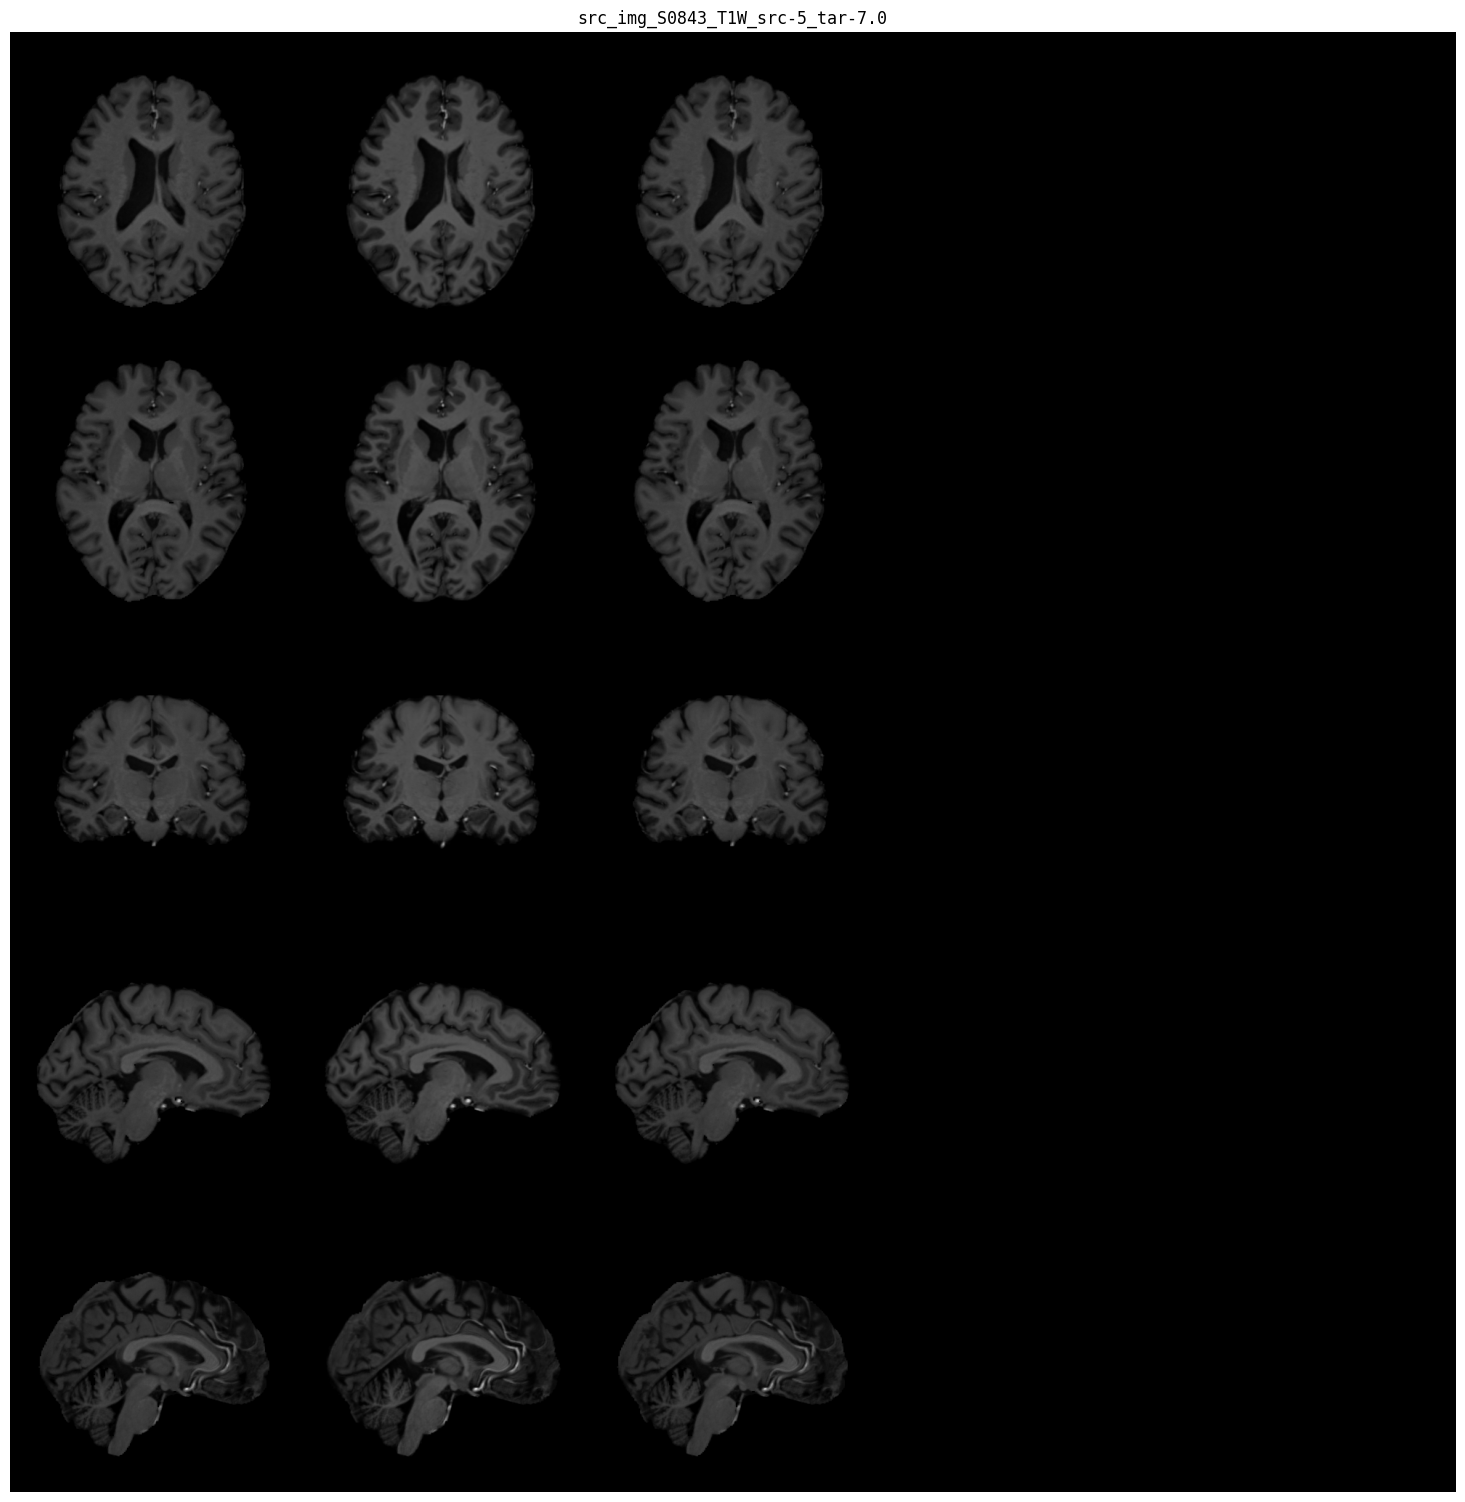

zero latent for batch 0, modality 0 due to missing modality shape: torch.Size([4, 96, 112, 96])
zero latent for batch 0, modality 1 due to missing modality shape: torch.Size([4, 96, 112, 96])
Latents shape: torch.Size([2, 12, 96, 112, 96])


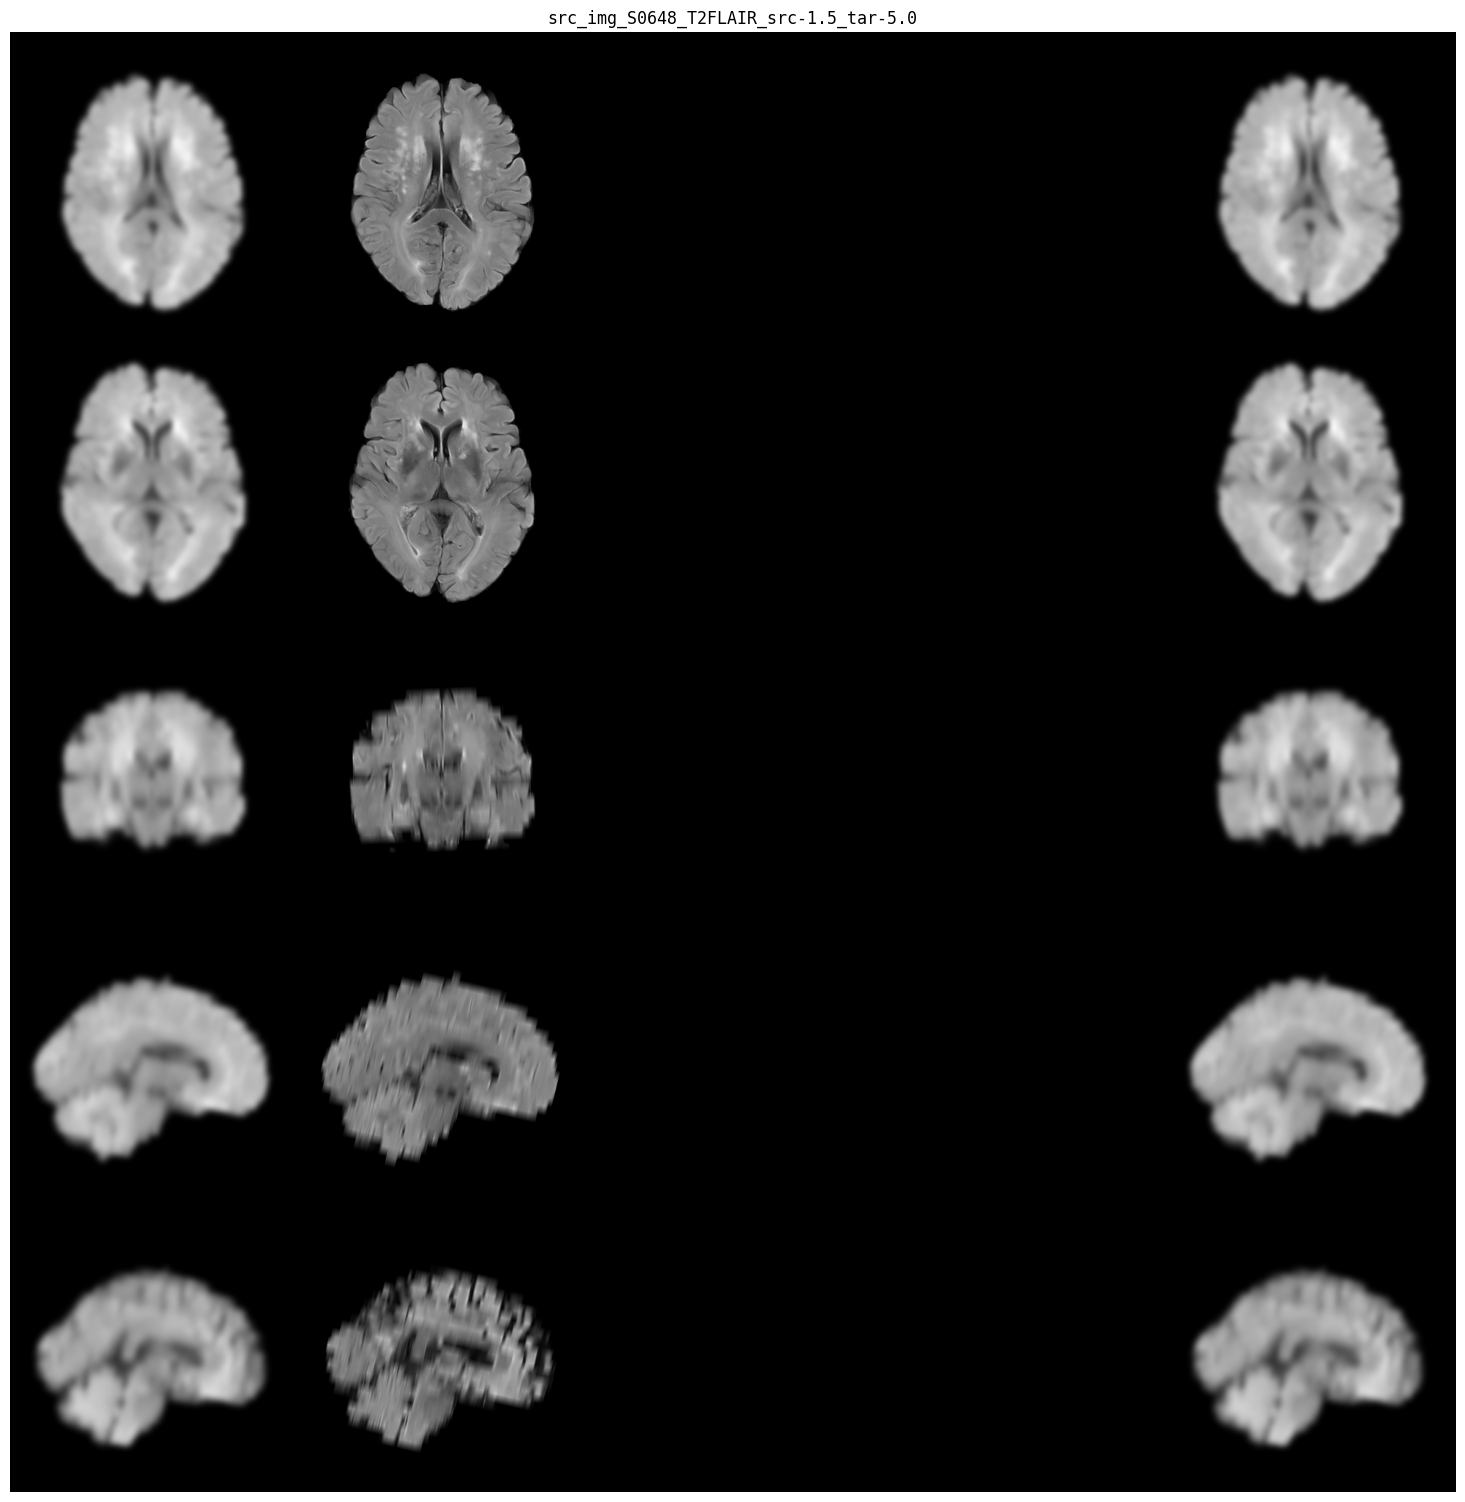

zero latent for batch 0, modality 1 due to missing modality shape: torch.Size([4, 96, 112, 96])
zero latent for batch 0, modality 2 due to missing modality shape: torch.Size([4, 96, 112, 96])
zero latent for batch 1, modality 0 due to missing modality shape: torch.Size([4, 96, 112, 96])
zero latent for batch 1, modality 1 due to missing modality shape: torch.Size([4, 96, 112, 96])
Latents shape: torch.Size([2, 12, 96, 112, 96])


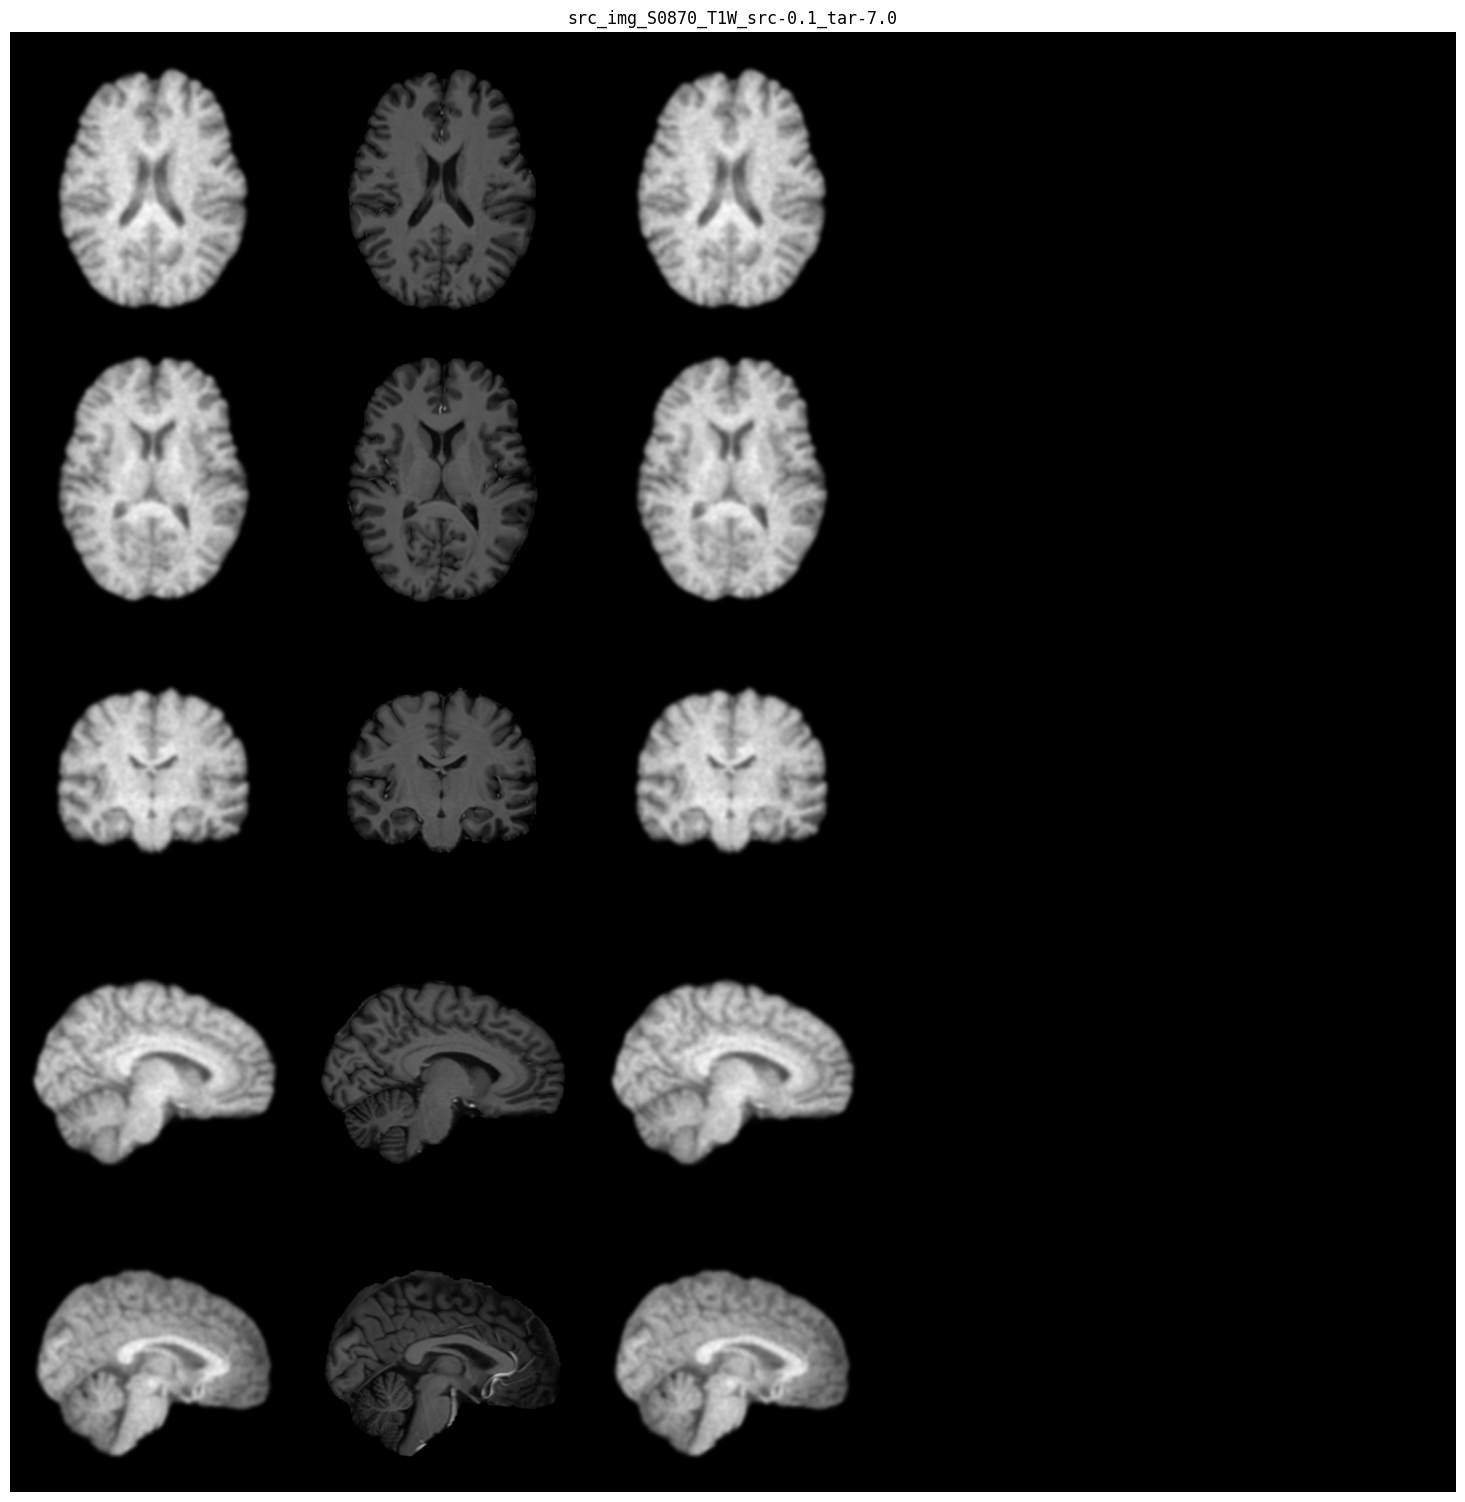

zero latent for batch 0, modality 0 due to missing modality shape: torch.Size([4, 96, 112, 96])
Latents shape: torch.Size([2, 12, 96, 112, 96])


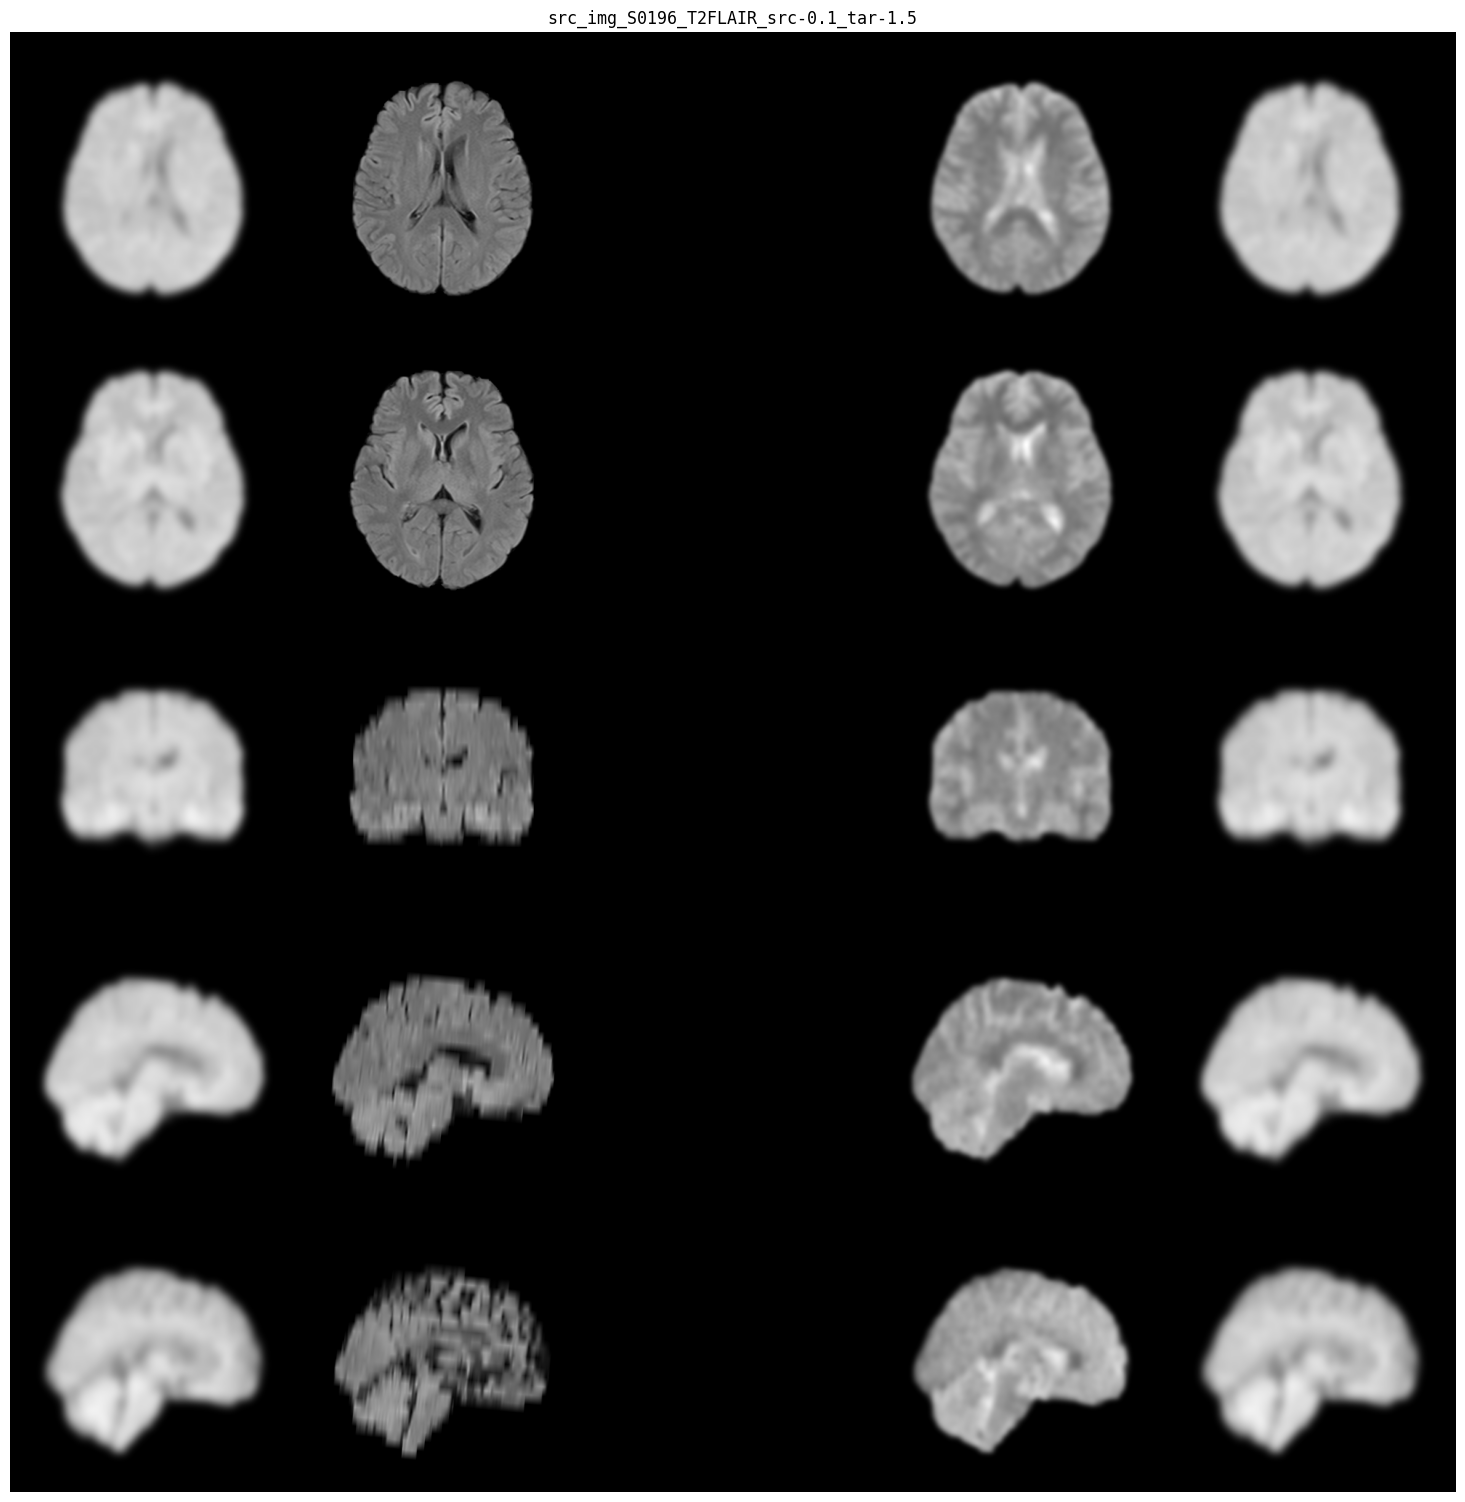

In [11]:

for i, batch in enumerate(train_dataloader):
    src_img = batch["src_img"][0].squeeze().numpy()
    tar_img = batch["tar_img"][0].squeeze().numpy()

    other_modalities = []
    for mod_idx, mod in enumerate(args_train.used_modalities):
        if batch["mask_available_modalities"][0][mod_idx] == 1:
            other_modalities.append(batch["src_img_modalities"][0][mod_idx].squeeze().numpy())
        else:
            other_modalities.append(np.zeros_like(src_img))
    
    latent_dim = tuple(batch["tar_latent"].shape[1:])  # Assuming latent dimension is the second dimension of tar_latent
    latents = encode_batch(autoencoder, batch["src_img_modalities"].to(device), batch["mask_available_modalities"].to(device), latent_dim)
    print(f"Latents shape: {latents.shape}")
    visualize_multiple_layers(
        [src_img, tar_img] + other_modalities,
        figsize=(20, 20),
        name=f"src_img_{batch['subject_id'][0]}_{batch['modality'][0]}_src-{batch['src_resolution'][0]}_tar-{batch['tar_resolution'][0]}",
        # custom_disposition=(1, 2)
    )

    if i == 3:
        break  # Remove this break if you want to visualize more batches